In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
#!pip install scikit-learn
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Breast_Cancer.csv')
data.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [ ]:
print(data.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')


In [ ]:
data['Status'].value_counts()

,count
Status,
Alive,3408
Dead,616


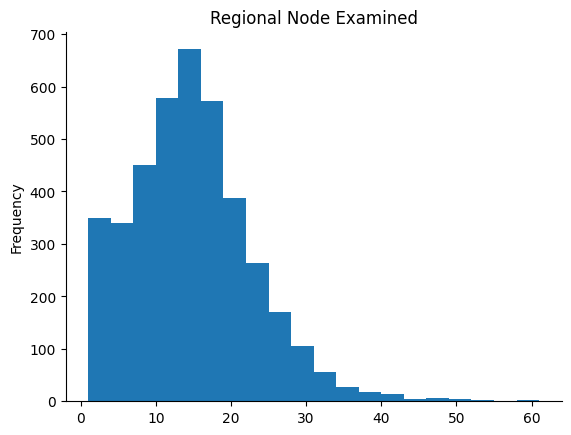

In [ ]:
data['Regional Node Examined'].plot(kind='hist', bins=20, title='Regional Node Examined')
plt.gca().spines[['top', 'right',]].set_visible(False)

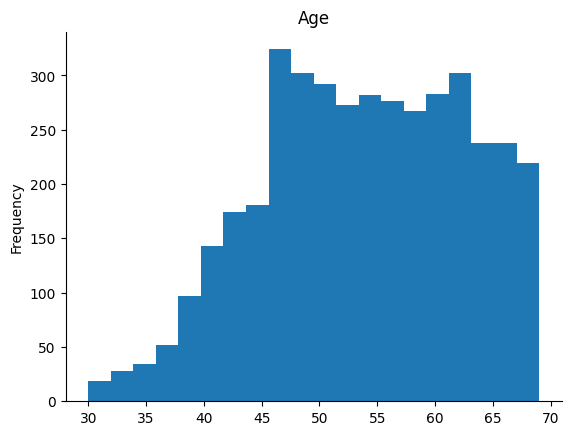

In [ ]:
data['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

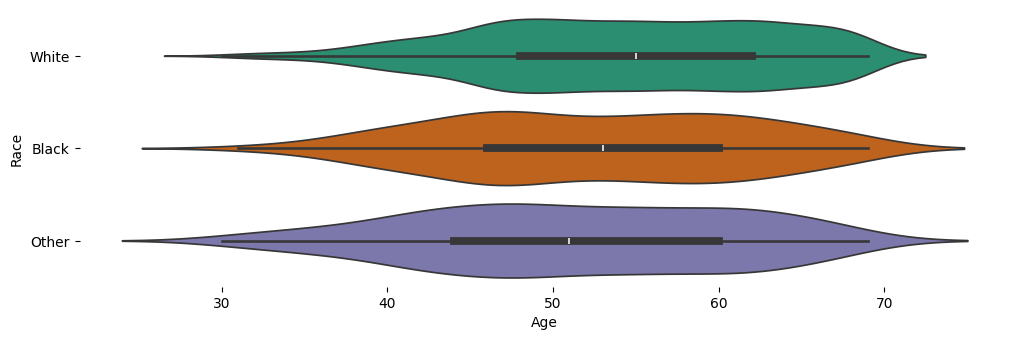

In [ ]:
figsize = (12, 1.2 * len(data['Race'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(data, x='Age', y='Race', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
binary_cols = ['A Stage', 'Estrogen Status', 'Progesterone Status']

for col in binary_cols:
    unique_values = data[col].unique()

    if len(unique_values) == 2:
        mapping = {unique_values[0]: 1, unique_values[1]: 0}
        data[col] = data[col].replace(mapping)
        data[col] = pd.to_numeric(data[col])

In [ ]:
data['Grade'] = data['Grade'].replace(' anaplastic; Grade IV', '4')
data['Grade'] = pd.to_numeric(data['Grade'])

data['differentiate'] = data['differentiate'].replace({'Undifferentiated': 0, 'Poorly differentiated': 1, 'Moderately differentiated': 2, 'Well differentiated': 3})
data['differentiate'] = pd.to_numeric(data['differentiate'])

data['T Stage '] = data['T Stage '].replace({'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4})
data['T Stage '] = pd.to_numeric(data['T Stage '])

data['N Stage'] = data['N Stage'].replace({'N1': 1, 'N2': 2, 'N3': 3})
data['N Stage'] = pd.to_numeric(data['N Stage'])

#Target
data['Status'] = data['Status'].replace({'Alive': 0, 'Dead': 1})
data['Status'] = pd.to_numeric(data['Status'])


In [ ]:
data.select_dtypes(include='object').nunique()

,0
Race,3
Marital Status,5
6th Stage,5


In [ ]:
object_cols = data.select_dtypes(include='object').columns

if len(object_cols) > 0:
    data = pd.get_dummies(data, columns=object_cols, drop_first=True).astype(int)

data.head()

,Age,T Stage,N Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,...,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,6th Stage_IIB,6th Stage_IIIA,6th Stage_IIIB,6th Stage_IIIC
0,68,1,1,1,3,1,4,1,1,24,...,0,1,1,0,0,0,0,0,0,0
1,50,2,2,2,2,1,35,1,1,14,...,0,1,1,0,0,0,0,1,0,0
2,58,3,3,2,2,1,63,1,1,14,...,0,1,0,0,0,0,0,0,0,1
3,58,1,1,1,3,1,18,1,1,2,...,0,1,1,0,0,0,0,0,0,0
4,47,2,1,1,3,1,41,1,1,3,...,0,1,1,0,0,0,1,0,0,0


In [ ]:
X = data.drop(columns="Status")
y = data.loc[:,"Status"]

scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size=0.2 , stratify=y , shuffle=True, random_state= 162)
X.head()

,Age,T Stage,N Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,...,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,6th Stage_IIB,6th Stage_IIIA,6th Stage_IIIB,6th Stage_IIIC
0,1.565253,-1.025287,-0.632209,-1.331031,1.331031,0.152963,-1.253661,0.267652,0.458107,1.190676,...,-0.293927,0.423109,0.722850,-0.106346,-0.424741,-0.249041,-0.624870,-0.594188,-0.130123,-0.364531
1,-0.443222,0.281158,0.809974,0.235987,-0.235987,0.152963,0.214345,0.267652,0.458107,-0.044095,...,-0.293927,0.423109,0.722850,-0.106346,-0.424741,-0.249041,-0.624870,1.682968,-0.130123,-0.364531
2,0.449434,1.587604,2.252157,0.235987,-0.235987,0.152963,1.540287,0.267652,0.458107,-0.044095,...,-0.293927,0.423109,-1.383413,-0.106346,-0.424741,-0.249041,-0.624870,-0.594188,-0.130123,2.743251
3,0.449434,-1.025287,-0.632209,-1.331031,1.331031,0.152963,-0.590691,0.267652,0.458107,-1.525820,...,-0.293927,0.423109,0.722850,-0.106346,-0.424741,-0.249041,-0.624870,-0.594188,-0.130123,-0.364531
4,-0.777968,0.281158,-0.632209,-1.331031,1.331031,0.152963,0.498475,0.267652,0.458107,-1.402343,...,-0.293927,0.423109,0.722850,-0.106346,-0.424741,-0.249041,1.600332,-0.594188,-0.130123,-0.364531


In [ ]:
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer

continuous_features = X_train.nunique()[X_train.nunique() > 10].index.tolist()

skewness = X_train[continuous_features].skew()
skewed_features = skewness[abs(skewness) > 0.5].index.tolist()

print(f"Continuous features: {len(continuous_features)}")
print(f"Skewed features to transform: {skewed_features}")

pt = PowerTransformer(method='yeo-johnson')
X_train[skewed_features] = pt.fit_transform(X_train[skewed_features])
X_test[skewed_features] = pt.transform(X_test[skewed_features])

print(f"Transformed {len(skewed_features)} skewed features")

Continuous features: 5
Skewed features to transform: ['Tumor Size', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months']
Transformed 4 skewed features


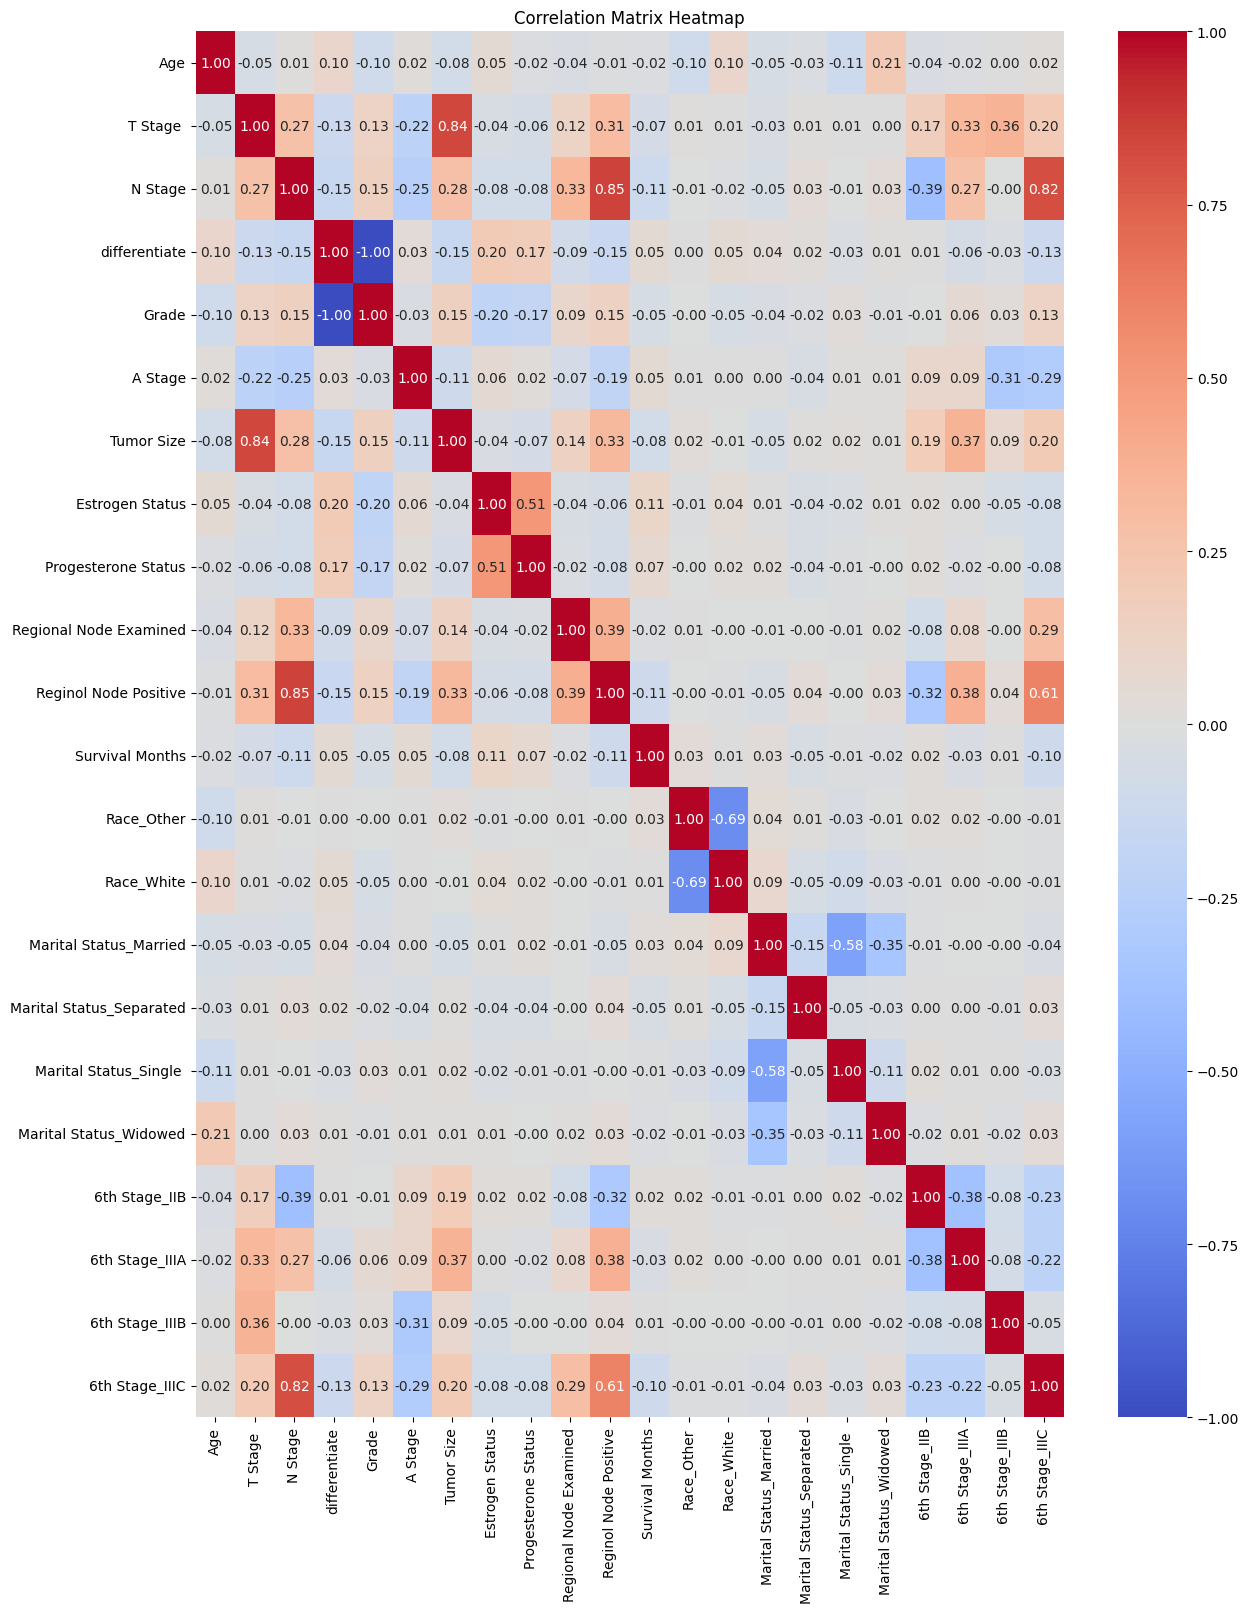

In [ ]:
correlation_matrix = X_train.corr()
plt.figure(figsize=(14,18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
def remove_correlated_features(df, threshold=0.80):
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = [column for column in upper_tri.columns
               if any(upper_tri[column] > threshold)]

    return df.drop(columns=to_drop), to_drop

X_train, dropped_cols = remove_correlated_features(X_train, threshold=0.80)
X_test = X_test[X_train.columns]

print(f"Dropped {len(dropped_cols)} features: {dropped_cols}")
print(f"Remaining features: {X_train.shape[1]}")

Dropped 4 features: ['Grade', 'Tumor Size', 'Reginol Node Positive', '6th Stage_IIIC']
Remaining features: 18


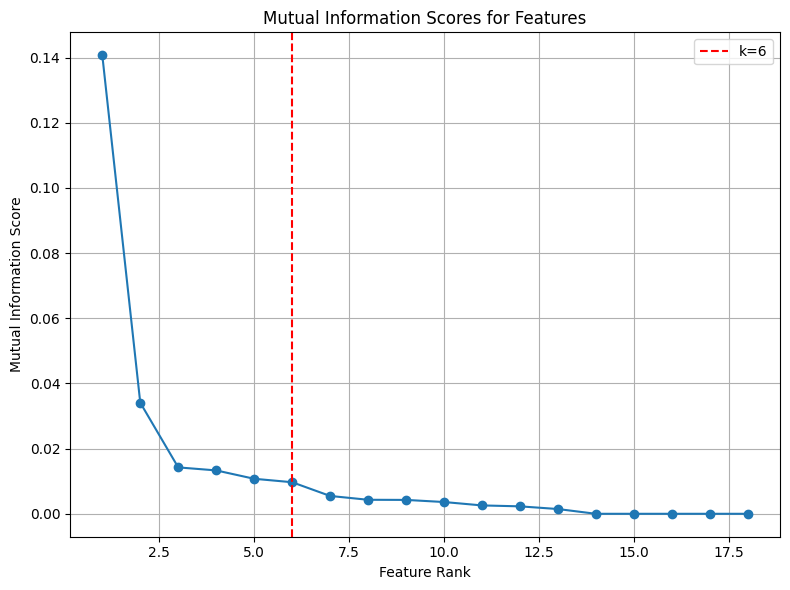

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Get mutual information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=162)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(mi_series)+1), mi_series.values, marker='o')
plt.title("Mutual Information Scores for Features")
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information Score")
plt.grid(True)

plt.axvline(x=6, color='red', linestyle='--', label='k=6')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
k = 6
selector = SelectKBest(score_func=mutual_info_classif, k=k)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print("Top-k selected features:")
print(selected_features.tolist())

X_train=pd.DataFrame(X_train_selected, columns=selected_features)
X_test=pd.DataFrame(X_test_selected, columns=selected_features)

Top-k selected features:
['T Stage ', 'N Stage', 'differentiate', 'Estrogen Status', 'Survival Months', 'Marital Status_Married']


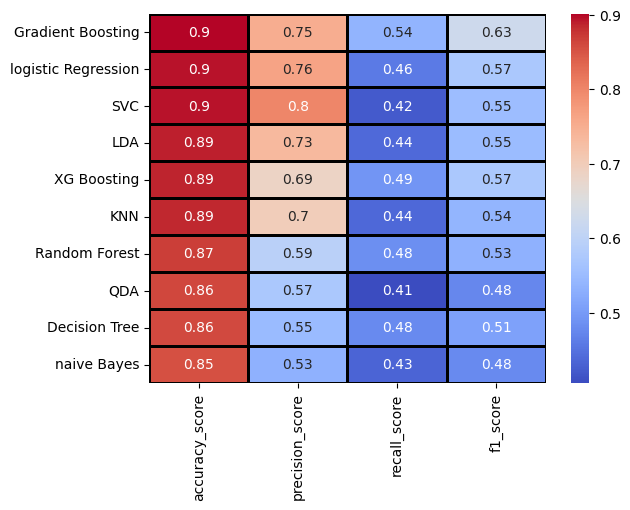

In [ ]:
from sklearn.model_selection import cross_validate

model_dic={
    'logistic Regression':LogisticRegression(),
    "Decision Tree":DTC(criterion='entropy'),
    'LDA':LDA(),
    'QDA':QDA(),
    'Random Forest':RandomForestClassifier(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "naive Bayes":GaussianNB(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    cv_results = cross_validate(model, X_train, y_train, cv=5,
                                scoring=['accuracy', 'precision', 'recall', 'f1'])

    acc_dic[i]={
        'accuracy_score': cv_results['test_accuracy'].mean(),
        'precision_score': cv_results['test_precision'].mean(),
        'recall_score': cv_results['test_recall'].mean(),
        'f1_score': cv_results['test_f1'].mean()
    }

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by='accuracy_score', ascending=False)

sns.heatmap(acc_dic_sorted, cmap="coolwarm", annot=True, linecolor="black", linewidths=1)
plt.show()

In [ ]:
# Optimize hyperparamters
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=162),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

class_weight = {0: 1, 1: 85/15}
sample_weights = np.array([class_weight[label] for label in y_train])

grid_search.fit(X_train, y_train,sample_weight=sample_weights)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV recall score: {grid_search.best_score_:.4f}")

best_gb_model = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}
Best CV recall score: 0.7320


Optimal threshold (max F2): 0.164
Precision: 0.594
Recall: 0.755
F2-Score: 0.716


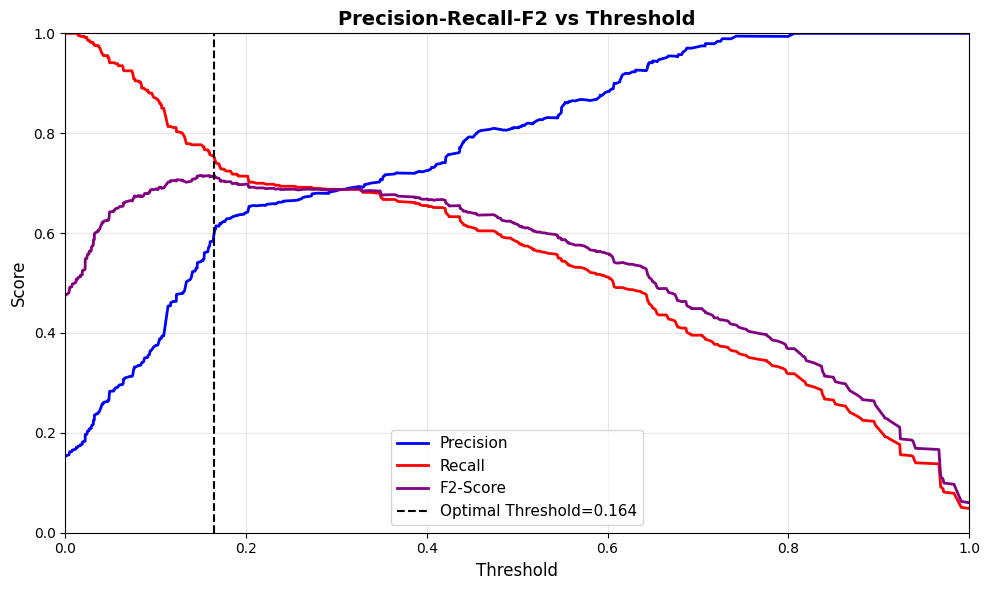

In [ ]:
from sklearn.metrics import precision_recall_curve, fbeta_score
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_gb_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

y_train_proba = calibrated_model.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)

f2_scores = (5 * precisions[:-1] * recalls[:-1]) / (4 * precisions[:-1] + recalls[:-1])

optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (max F2): {optimal_threshold:.3f}")
print(f"Precision: {precisions[optimal_idx]:.3f}")
print(f"Recall: {recalls[optimal_idx]:.3f}")
print(f"F2-Score: {f2_scores[optimal_idx]:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'r-', label='Recall', linewidth=2)
plt.plot(thresholds, f2_scores, 'purple', label='F2-Score', linewidth=2)
plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal Threshold={optimal_threshold:.3f}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision-Recall-F2 vs Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

print("="*50)
print("FINAL TEST SET PERFORMANCE")
print("="*50)
print(classification_report(y_test, y_test_pred, target_names=['Alive', 'Dead']))

FINAL TEST SET PERFORMANCE
              precision    recall  f1-score   support

       Alive       0.93      0.89      0.91       682
        Dead       0.51      0.61      0.56       123

    accuracy                           0.85       805
   macro avg       0.72      0.75      0.73       805
weighted avg       0.86      0.85      0.86       805



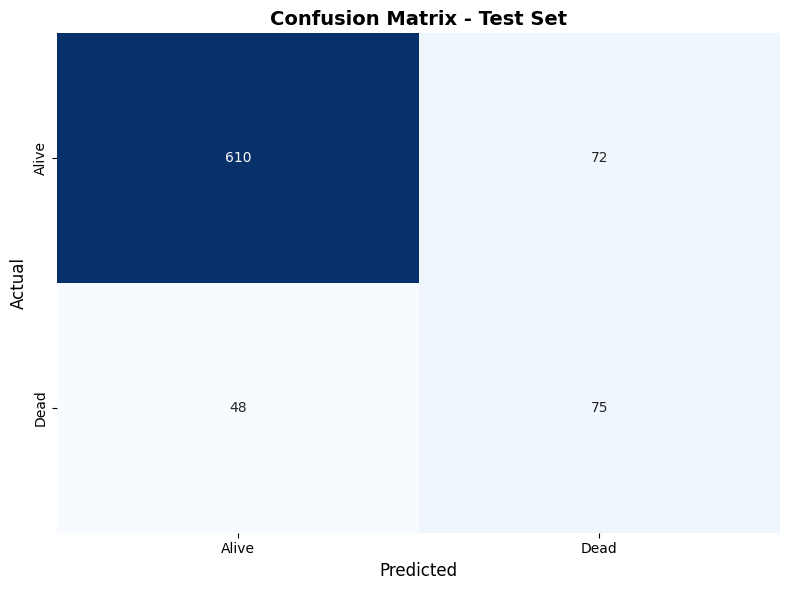

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

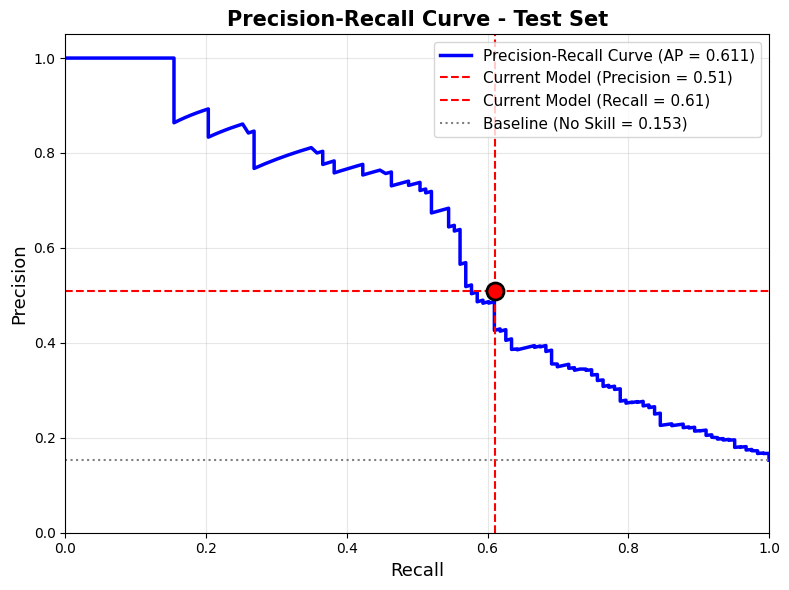

In [ ]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, color='blue', lw=2.5, label=f'Precision-Recall Curve (AP = {avg_precision:.3f})')
plt.axhline(y=0.51, color='red', linestyle='--', lw=1.5, label=f'Current Model (Precision = 0.51)')
plt.axvline(x=0.61, color='red', linestyle='--', lw=1.5, label=f'Current Model (Recall = 0.61)')
plt.scatter([0.61], [0.51], color='red', s=150, zorder=5, edgecolors='black', linewidth=2)

baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle=':', lw=1.5, label=f'Baseline (No Skill = {baseline:.3f})')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve - Test Set', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

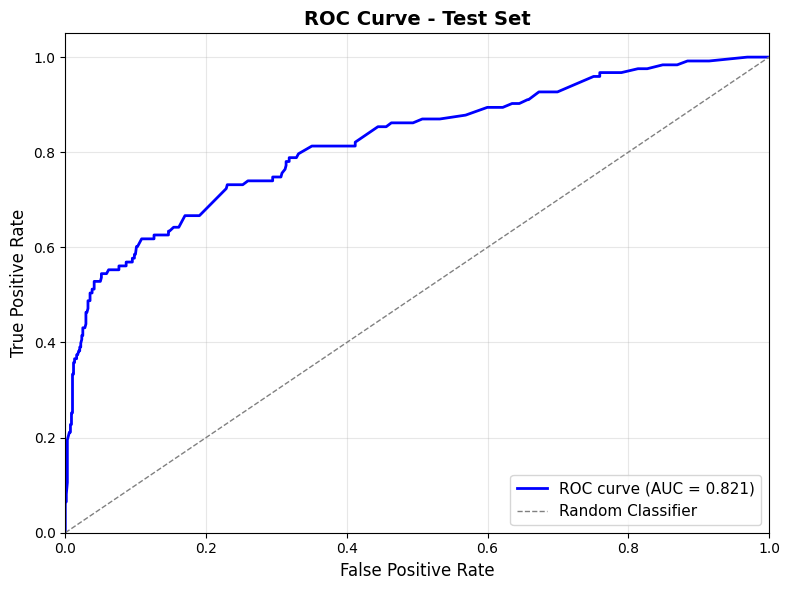

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

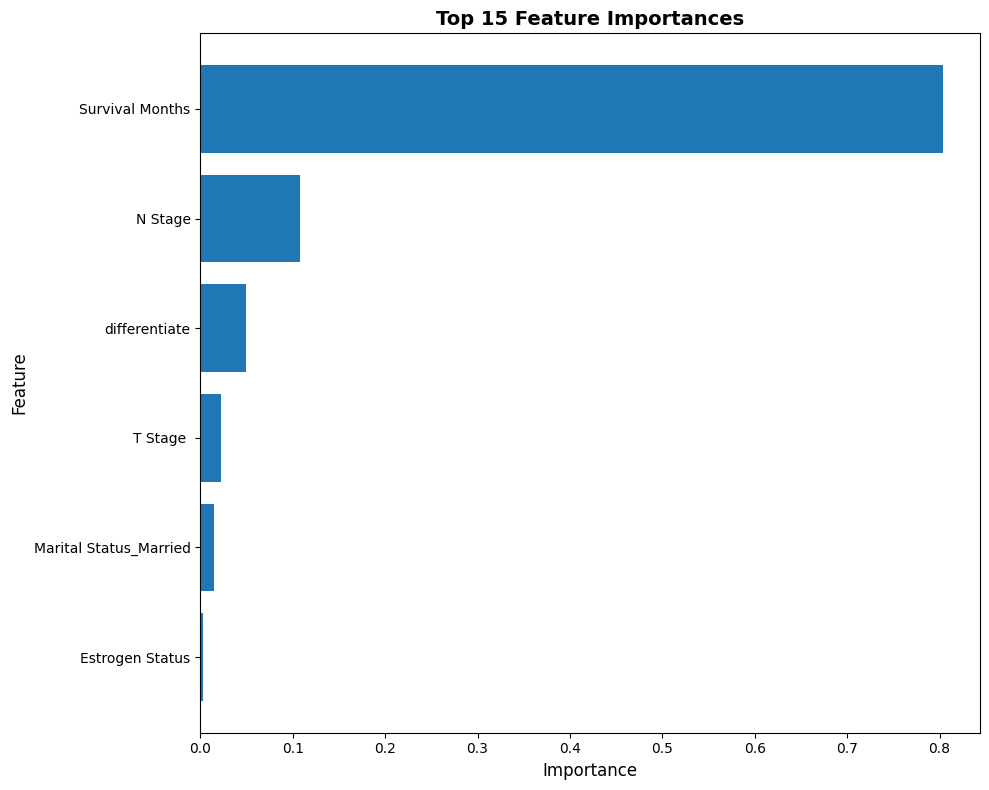

                  feature  importance
4         Survival Months    0.803521
1                 N Stage    0.107764
2           differentiate    0.049024
0                T Stage     0.022542
5  Marital Status_Married    0.014411
3         Estrogen Status    0.002738


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_gb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:6], feature_importance['importance'][:6])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.head(6))

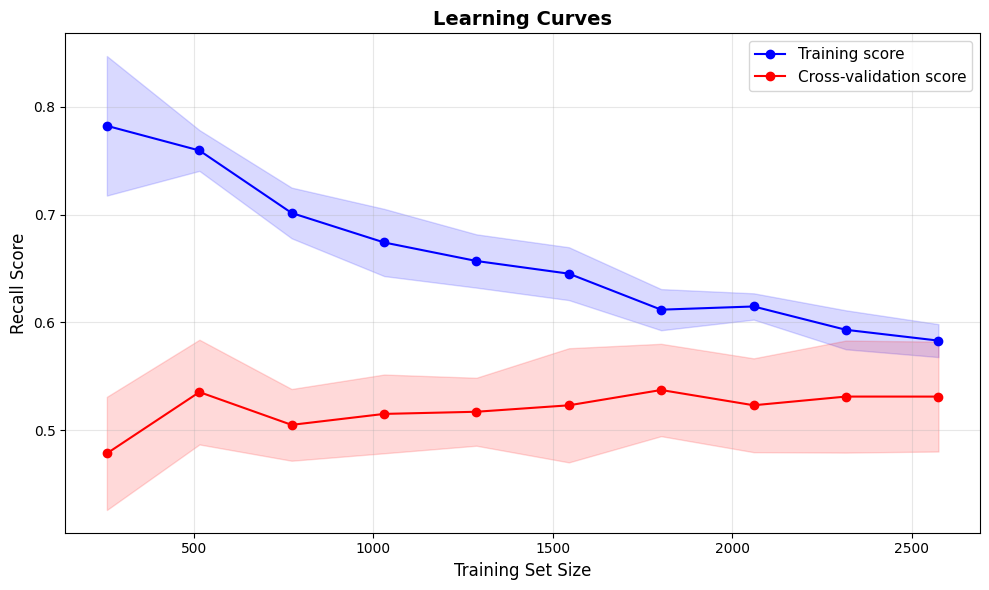

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_gb_model, X_train, y_train, cv=5,
    scoring='recall', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, label='Cross-validation score', color='red', marker='o')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Recall Score', fontsize=12)
plt.title('Learning Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Training threshold: {optimal_threshold:.3f}")
print(f"Mean predicted probability on train (dead class): {y_train_proba[y_train==1].mean():.3f}")

y_test_proba = best_gb_model.predict_proba(X_test)[:, 1]
print(f"Mean predicted probability on test (dead class): {y_test_proba[y_test==1].mean():.3f}")

Training threshold: 0.164
Mean predicted probability on train (dead class): 0.544
Mean predicted probability on test (dead class): 0.651
